# Disease Type Prediction Analysis (training.py)

This notebook analyzes grid outputs created by `src/training/training.py` for disease type classification.
It merges **all** `grid_summary.json` files under the results root (unless you pin a specific run),
selects the best run per model family and modality (pure, progression, cultivar, both), and plots:
- Best pure/progression/cultivar/both per model family (grouped bars)
- Per-model panels (one panel per model family)
- Best overall result per model family (comparison)


In [159]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Config
RESULTS_ROOT = Path("/mnt/slowdisk/public/HIPPA/multiclass_classification/results")
RUN_ROOT = None  # e.g., Path("/mnt/slowdisk/public/HIPPA/multiclass_classification/results/hippa_grid_YYYYMMDD-HHMMSS")
MERGE_ALL = True
EXTRA_SUMMARIES = []  # Optional list of explicit grid_summary.json paths

EXPECTED_BASE_MODELS = [
    "conv4",
    "resnet18",
    # "tian_irv2",  # missing in current merged results
    "tian_v4",
    "resnet152",
]
MODALITIES = ["pure", "cult", "prog", "both"]

plt.style.use("seaborn-v0_8-whitegrid")


In [160]:
def collect_grid_summaries():
    if RUN_ROOT is not None:
        summary = Path(RUN_ROOT) / "grid_summary.json"
        if not summary.exists():
            raise FileNotFoundError(f"Missing grid_summary.json at {summary}")
        return [summary]

    summaries = []
    if MERGE_ALL and RESULTS_ROOT.exists():
        summaries = sorted(RESULTS_ROOT.rglob("grid_summary.json"))

    for extra in EXTRA_SUMMARIES:
        p = Path(extra)
        if p.exists():
            summaries.append(p)

    if not summaries:
        search_roots = [
            RESULTS_ROOT,
            Path.cwd().parent.parent / "results",
            Path.cwd() / "results",
            Path.cwd(),
        ]
        for root in search_roots:
            if root.exists():
                summaries.extend(root.rglob("grid_summary.json"))
        summaries = sorted(set(summaries))

    if not summaries:
        raise FileNotFoundError("No grid_summary.json found. Set RUN_ROOT or RESULTS_ROOT.")

    return summaries

summary_paths = collect_grid_summaries()
print(f"Found {len(summary_paths)} grid_summary.json file(s)")
for p in summary_paths:
    print(f"- {p}")

runs = []
for summary_path in summary_paths:
    with open(summary_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        continue
    for row in data:
        if not isinstance(row, dict):
            continue
        row = dict(row)
        row.setdefault("grid_summary", str(summary_path))
        row.setdefault("grid_root", str(summary_path.parent))
        runs.append(row)

df = pd.DataFrame(runs)
if df.empty:
    raise ValueError("No runs found after merging grid summaries.")
df.head()


Found 4 grid_summary.json file(s)
- /mnt/slowdisk/public/HIPPA/multiclass_classification/results/conv4dcnn_fusion_grid_20251227-105738/grid_summary.json
- /mnt/slowdisk/public/HIPPA/multiclass_classification/results/conv4dcnn_fusion_grid_20251230-075716/grid_summary.json
- /mnt/slowdisk/public/HIPPA/multiclass_classification/results/conv4dcnn_fusion_grid_20260102-081828/grid_summary.json
- /mnt/slowdisk/public/HIPPA/multiclass_classification/results/hippa_grid_20260107-151116/grid_summary.json


,combo,variant,dir,best_val_loss,best_epoch,final_val_acc,hparams,grid_summary,grid_root
0,conv4_pure_drop0.3_lr0.0003_optadam,conv4_pure,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,1.083301,19,0.627954,"{'dropout': 0.3, 'learning_rate': 0.0003, 'opt...",/mnt/slowdisk/public/HIPPA/multiclass_classifi...,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
1,conv4_pure_drop0.3_lr0.0001_optadam,conv4_pure,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,1.469294,7,0.484142,"{'dropout': 0.3, 'learning_rate': 0.0001, 'opt...",/mnt/slowdisk/public/HIPPA/multiclass_classifi...,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
2,conv4_pure_drop0.3_lr3e-05_optadam,conv4_pure,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,1.587298,12,0.421642,"{'dropout': 0.3, 'learning_rate': 3e-05, 'opti...",/mnt/slowdisk/public/HIPPA/multiclass_classifi...,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
3,conv4_cult_concat_drop0.3_lr0.0003_optadam,conv4_cult_concat,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.871941,17,0.612251,"{'dropout': 0.3, 'learning_rate': 0.0003, 'opt...",/mnt/slowdisk/public/HIPPA/multiclass_classifi...,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
4,conv4_cult_concat_drop0.3_lr0.0001_optadam,conv4_cult_concat,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,1.137780,9,0.575560,"{'dropout': 0.3, 'learning_rate': 0.0001, 'opt...",/mnt/slowdisk/public/HIPPA/multiclass_classifi...,/mnt/slowdisk/public/HIPPA/multiclass_classifi...


In [161]:
def parse_variant(name):
    tokens = str(name).split("_")
    for i, tok in enumerate(tokens):
        if tok in ("cult", "prog", "both", "pure"):
            base = "_".join(tokens[:i]) if i > 0 else str(name)
            modality = tok
            fusion = "_".join(tokens[i + 1 :]) if i + 1 < len(tokens) else ""
            return base, modality, fusion
    return str(name), "unknown", ""

def normalize_base_model(name):
    mapping = {"res18": "resnet18", "res152": "resnet152"}
    return mapping.get(name, name)

parsed = df["variant"].apply(lambda v: pd.Series(parse_variant(v)))
parsed.columns = ["base_model", "modality", "fusion"]
df = pd.concat([df, parsed], axis=1)
df["base_model"] = df["base_model"].apply(normalize_base_model)

df["final_val_acc"] = pd.to_numeric(df.get("final_val_acc"), errors="coerce")
df["best_val_loss"] = pd.to_numeric(df.get("best_val_loss"), errors="coerce")

df[["variant", "base_model", "modality", "fusion", "final_val_acc", "best_val_loss"]].head()


,variant,base_model,modality,fusion,final_val_acc,best_val_loss
0,conv4_pure,conv4,pure,,0.627954,1.083301
1,conv4_pure,conv4,pure,,0.484142,1.469294
2,conv4_pure,conv4,pure,,0.421642,1.587298
3,conv4_cult_concat,conv4,cult,concat,0.612251,0.871941
4,conv4_cult_concat,conv4,cult,concat,0.575560,1.137780


In [162]:
def select_best(group):
    group = group.copy()
    if group["final_val_acc"].notna().any():
        return group.loc[group["final_val_acc"].idxmax()]
    return group.loc[group["best_val_loss"].idxmin()]

df_modes = df[df["modality"].isin(MODALITIES)].copy()
best_rows = []
for (base_model, modality), group in df_modes.groupby(["base_model", "modality"]):
    group = group.dropna(subset=["final_val_acc", "best_val_loss"], how="all")
    if group.empty:
        continue
    best_rows.append(select_best(group))

best_df = pd.DataFrame(best_rows)
best_df = best_df.sort_values(["base_model", "modality"])
best_df[["base_model", "modality", "variant", "dir", "final_val_acc", "best_val_loss"]]


,base_model,modality,variant,dir,final_val_acc,best_val_loss
19,conv4,both,conv4_both_sum,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.764148,0.565671
30,conv4,cult,conv4_cult_concat+sum+prod,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.655784,0.868277
24,conv4,prog,conv4_prog_prod,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.735852,0.714500
0,conv4,pure,conv4_pure,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.627954,1.083301
66,resnet152,both,res152_both_prod,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.894745,0.333411
42,resnet152,cult,res152_cult_concat,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.815454,0.524155
72,resnet152,prog,res152_prog_concat+sum+prod,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.886194,0.325684
39,resnet152,pure,resnet152_pure,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.784515,0.592806
105,resnet18,both,res18_both_prod,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.882463,0.312113
90,resnet18,cult,res18_cult_sum,/mnt/slowdisk/public/HIPPA/multiclass_classifi...,0.797575,0.572909


In [163]:
def load_val_accuracy(run_dir):
    pred_path = Path(run_dir) / "val_predictions.csv"
    if not pred_path.exists():
        return None, None
    preds = pd.read_csv(pred_path)
    if preds.empty:
        return None, None
    preds["correct"] = preds["true_label"].astype(str) == preds["pred_label"].astype(str)
    overall_acc = float(preds["correct"].mean())
    per_class = preds.groupby("true_label")["correct"].mean().sort_index()
    return overall_acc, per_class

accs = []
per_class_map = {}
for row in best_df.itertuples(index=False):
    acc, per_class = load_val_accuracy(row.dir)
    accs.append(acc)
    per_class_map[(row.base_model, row.modality)] = per_class

best_df["val_acc_from_preds"] = accs
best_df["metric"] = best_df["val_acc_from_preds"].fillna(best_df["final_val_acc"])
best_df[["base_model", "modality", "metric", "dir"]]


,base_model,modality,metric,dir
19,conv4,both,0.774953,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
30,conv4,cult,0.680791,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
24,conv4,prog,0.744821,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
0,conv4,pure,0.610169,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
66,resnet152,both,0.886064,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
42,resnet152,cult,0.810264,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
72,resnet152,prog,0.878060,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
39,resnet152,pure,0.805085,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
105,resnet18,both,0.878060,/mnt/slowdisk/public/HIPPA/multiclass_classifi...
90,resnet18,cult,0.767420,/mnt/slowdisk/public/HIPPA/multiclass_classifi...


In [164]:
missing = best_df[best_df["val_acc_from_preds"].isna()]
if not missing.empty:
    print("Runs missing val_predictions.csv (showing up to 5):")
    for p in missing["dir"].head(5):
        print("-", p)


In [165]:
extra_models = sorted(set(best_df["base_model"]) - set(EXPECTED_BASE_MODELS))
base_models = EXPECTED_BASE_MODELS + extra_models

plot_df = best_df.pivot(index="base_model", columns="modality", values="metric")
plot_df = plot_df.reindex(base_models)
for col in MODALITIES:
    if col not in plot_df.columns:
        plot_df[col] = np.nan
plot_df = plot_df[MODALITIES]

missing_models = plot_df.index[plot_df.isna().all(axis=1)].tolist()
if missing_models:
    print("No data for:", ", ".join(missing_models))
    plot_df = plot_df.drop(index=missing_models)

plot_df


modality,pure,cult,prog,both
base_model,,,,
conv4,0.610169,0.680791,0.744821,0.774953
resnet18,0.750471,0.767420,0.859228,0.878060
tian_v4,0.741055,0.736817,0.811205,0.811676
resnet152,0.805085,0.810264,0.878060,0.886064


In [166]:
def annotate_bars(ax):
    for bar in ax.patches:
        height = bar.get_height()
        if np.isnan(height):
            continue
        ax.annotate(
            f"{height:.2f}",
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=0,
            xytext=(0, 2),
            textcoords="offset points",
        )


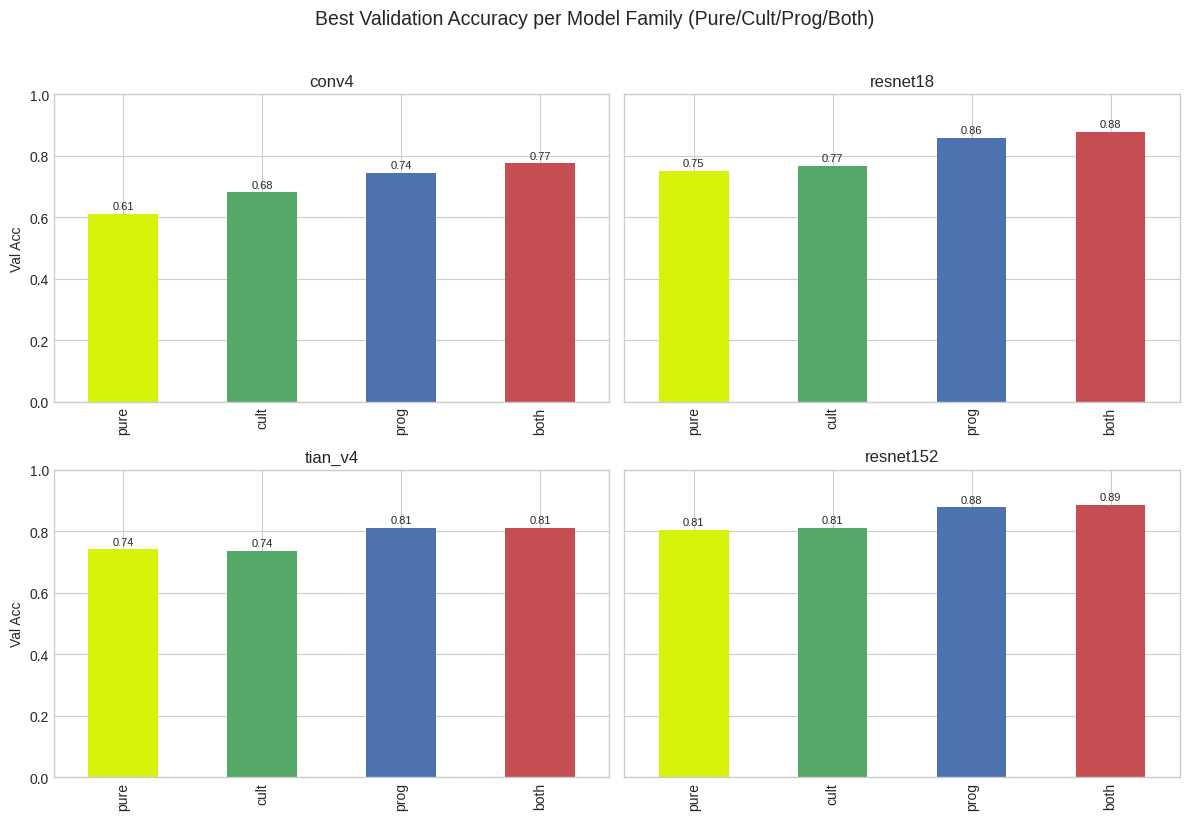

In [167]:
n_models = len(plot_df.index)
cols = 2 if n_models > 1 else 1
rows = int(np.ceil(n_models / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4), sharey=True)
if n_models == 1:
    axes = [axes]
else:
    axes = axes.flatten()

colors = {"pure": "#D6F208", "cult": "#55A868", "prog": "#4C72B0", "both": "#C44E52"}
for idx, base in enumerate(plot_df.index):
    ax = axes[idx]
    series = plot_df.loc[base]
    if series.isna().all():
        ax.text(0.5, 0.5, "no data", ha="center", va="center", fontsize=12)
        ax.set_title(base)
        ax.set_ylim(0.0, 1.0)
        ax.set_xticks([])
        continue
    series.plot(kind="bar", ax=ax, color=[colors[m] for m in MODALITIES])
    ax.set_title(base)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("")
    ax.set_ylabel("Val Acc")
    annotate_bars(ax)

for j in range(n_models, len(axes)):
    axes[j].axis("off")

fig.suptitle("Best Validation Accuracy per Model Family (Pure/Cult/Prog/Both)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


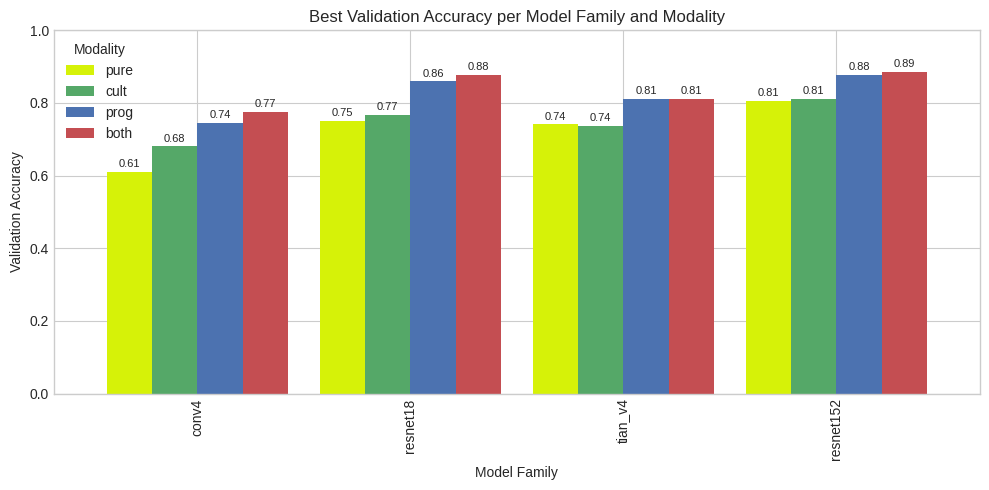

In [168]:
colors = {"pure": "#D6F208", "cult": "#55A868", "prog": "#4C72B0", "both": "#C44E52"}
ax = plot_df.plot(kind="bar", figsize=(10, 5), width=0.85, color=[colors[m] for m in MODALITIES])
ax.set_title("Best Validation Accuracy per Model Family and Modality")
ax.set_xlabel("Model Family")
ax.set_ylabel("Validation Accuracy")
ax.set_ylim(0.0, 1.0)
ax.legend(title="Modality")
annotate_bars(ax)
plt.tight_layout()
plt.show()


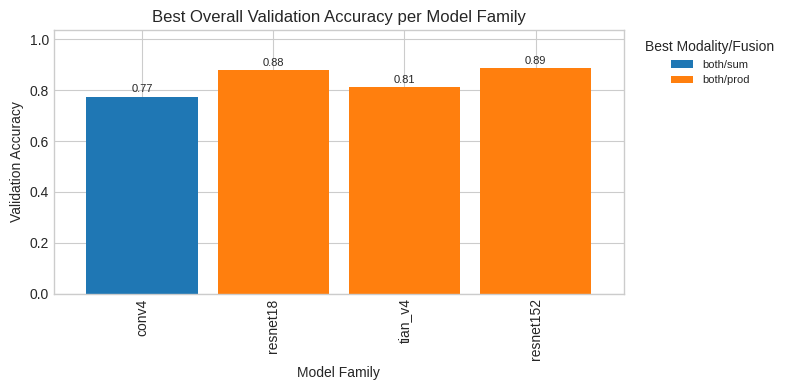

In [169]:
from matplotlib.patches import Patch

def simplify_fusion_mode(fm):
    if not fm:
        return ""
    fm_l = str(fm).lower()
    has_sum = "sum" in fm_l
    has_prod = "prod" in fm_l
    if has_sum and has_prod:
        return "sum+prod"
    if has_sum:
        return "sum"
    if has_prod:
        return "prod"
    return fm_l

def extract_fusion_mode(variant, modality):
    if not variant or modality in ("pure",):
        return ""
    tokens = str(variant).split("_")
    if modality in tokens:
        idx = tokens.index(modality)
        return "_".join(tokens[idx + 1 :])
    return ""

best_overall = plot_df.max(axis=1)
best_modality = plot_df.idxmax(axis=1)
variant_lookup = (
    best_df.set_index(["base_model", "modality"])["variant"]
    .to_dict()
)

labels = []
for base in best_overall.index:
    modality = best_modality.get(base, "")
    variant = variant_lookup.get((base, modality), "")
    fusion_mode = simplify_fusion_mode(extract_fusion_mode(variant, modality))
    if modality in ("cult", "both") and fusion_mode:
        label = f"{modality}/{fusion_mode}"
    else:
        label = str(modality)
    labels.append(label)

unique_labels = list(dict.fromkeys(labels))
cmap = plt.get_cmap("tab10")
label_colors = {label: cmap(i % cmap.N) for i, label in enumerate(unique_labels)}
bar_colors = [label_colors[label] for label in labels]

ax = best_overall.plot(kind="bar", figsize=(8, 4), width=0.85, color=bar_colors)
ax.set_title("Best Overall Validation Accuracy per Model Family")
ax.set_xlabel("Model Family")
ax.set_ylabel("Validation Accuracy")
y_top = max(1.0, float(best_overall.max()) + 0.15 if best_overall.notna().any() else 1.0)
ax.set_ylim(0.0, y_top)
annotate_bars(ax)

handles = [Patch(facecolor=label_colors[label], edgecolor="none") for label in unique_labels]
ax.legend(
    handles=handles,
    labels=unique_labels,
    title="Best Modality/Fusion",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    fontsize=8,
)

plt.tight_layout()
plt.show()


In [170]:
# Optional: show per-class accuracy for a chosen (base_model, modality)
# Example:
# key = ("tian_v4", "both")
# per_class_map.get(key)
